# KAN Benchmark Results: Publication-Style Tables

Comparative evaluation of Kolmogorov-Arnold Networks vs. baseline methods on sports injury datasets.

In [1]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

pd.set_option('display.precision', 3)

## Table 1: Dataset Details

Overview of the datasets used for benchmarking.

In [2]:
datasets = pd.DataFrame({
    'Dataset': ['High Accuracy Sport Injury', 'Player Injuries Impact'],
    'Abbreviation': ['HASI', 'PII'],
    'Type': ['Synthetic', 'Real (EPL)'],
    '# Classes': [2, 2],
    '# Samples': [600, 503],
    '# Features': [15, 6],
    'Task': ['Injury Risk', 'Performance Recovery']
})

print("Table 1: Dataset Characteristics")
print("=" * 80)
display(datasets.style.set_properties(**{'text-align': 'center'}).hide(axis='index'))

Table 1: Dataset Characteristics


Dataset,Abbreviation,Type,# Classes,# Samples,# Features,Task
High Accuracy Sport Injury,HASI,Synthetic,2,600,15,Injury Risk
Player Injuries Impact,PII,Real (EPL),2,503,6,Performance Recovery


## Table 2: Supervised Learning Results (Accuracy)

Comparison of models across both datasets. **Bold** indicates best performance per dataset.

In [3]:
# Results from our experiments
results = pd.DataFrame({
    'Method': [
        'XGBoost',
        'MLP',
        'LSTM',
        'efficient-kan',
        'FastKAN (RBF)',
        'FourierKAN',
        'ChebyKAN',
        'ChebyKAN (wide)',
        'Wav-KAN'
    ],
    'HASI (Acc)': [0.944, 0.856, 0.822, 0.822, 0.844, 0.689, 0.867, 0.800, 0.778],
    'HASI (AUC)': [0.906, 0.869, 0.848, 0.857, 0.885, 0.607, 0.811, 0.849, 0.796],
    'PII (Acc)':  [0.693, 0.693, None, None, None, None, 0.663, 0.743, None],
    'PII (AUC)':  [0.740, 0.746, None, None, None, None, 0.681, None, None],
})

# Calculate ranks
def calc_rank(s):
    return s.rank(ascending=False, na_option='bottom')

results['Rank HASI'] = calc_rank(results['HASI (Acc)'])
results['Rank PII'] = calc_rank(results['PII (Acc)'])
results['Avg Rank'] = results[['Rank HASI', 'Rank PII']].mean(axis=1)

results_sorted = results.sort_values('Avg Rank')

print("Table 2: Supervised Learning Benchmark Results")
print("=" * 80)
print("HASI = High Accuracy Sport Injury (Synthetic), PII = Player Injuries Impact (Real)")
print()

display_cols = ['Method', 'HASI (Acc)', 'HASI (AUC)', 'PII (Acc)', 'PII (AUC)', 'Avg Rank']

def highlight_best(s):
    if s.name in ['HASI (Acc)', 'HASI (AUC)', 'PII (Acc)', 'PII (AUC)']:
        is_max = s == s.max()
        return ['font-weight: bold; background-color: #90EE90' if v else '' for v in is_max]
    return ['' for _ in s]

styled = results_sorted[display_cols].style.apply(highlight_best).format(precision=3, na_rep='-').hide(axis='index')
display(styled)

Table 2: Supervised Learning Benchmark Results
HASI = High Accuracy Sport Injury (Synthetic), PII = Player Injuries Impact (Real)



Method,HASI (Acc),HASI (AUC),PII (Acc),PII (AUC),Avg Rank
XGBoost,0.944,0.906,0.693,0.740,1.750
MLP,0.856,0.869,0.693,0.746,2.750
ChebyKAN,0.867,0.811,0.663,0.681,3.000
ChebyKAN (wide),0.800,0.849,0.743,-,4.000
FastKAN (RBF),0.844,0.885,-,-,5.500
LSTM,0.822,0.848,-,-,6.250
efficient-kan,0.822,0.857,-,-,6.250
Wav-KAN,0.778,0.796,-,-,7.500
FourierKAN,0.689,0.607,-,-,8.000


## Table 3: ChebyKAN Hyperparameter Analysis

Ablation study on ChebyKAN architecture configurations.

In [4]:
chebykan_sweep = pd.DataFrame({
    'Configuration': ['Shallow, deg4', 'Wide, deg5', 'Wide, deg6', 'Deep, deg5', 'Shallow, deg5', 'Deep, deg6', 'Shallow, deg6'],
    'Architecture': ['[n,64,32,1]', '[n,100,50,1]', '[n,100,50,1]', '[n,128,64,32,1]', '[n,64,32,1]', '[n,128,64,32,1]', '[n,64,32,1]'],
    'Degree': [4, 5, 6, 5, 5, 6, 6],
    'HASI Acc': [0.844, 0.800, 0.789, 0.767, 0.756, 0.733, 0.733],
    'HASI AUC': [0.846, 0.849, 0.792, 0.739, 0.804, 0.720, 0.754],
})

chebykan_sweep['Rank'] = chebykan_sweep['HASI Acc'].rank(ascending=False).astype(int)
chebykan_sweep = chebykan_sweep.sort_values('Rank')

print("Table 3: ChebyKAN Configuration Analysis (HASI Dataset)")
print("=" * 80)
display(chebykan_sweep.style.format(precision=3).hide(axis='index'))

Table 3: ChebyKAN Configuration Analysis (HASI Dataset)


Configuration,Architecture,Degree,HASI Acc,HASI AUC,Rank
"Shallow, deg4","[n,64,32,1]",4,0.844,0.846,1
"Wide, deg5","[n,100,50,1]",5,0.800,0.849,2
"Wide, deg6","[n,100,50,1]",6,0.789,0.792,3
"Deep, deg5","[n,128,64,32,1]",5,0.767,0.739,4
"Shallow, deg5","[n,64,32,1]",5,0.756,0.804,5
"Deep, deg6","[n,128,64,32,1]",6,0.733,0.720,6
"Shallow, deg6","[n,64,32,1]",6,0.733,0.754,6


## Table 4: Key Findings Summary

In [5]:
findings = pd.DataFrame({
    'Dataset': ['HASI (Synthetic)', 'HASI (Synthetic)', 'PII (Real)', 'PII (Real)'],
    'Category': ['Best Overall', 'Best KAN', 'Best Overall', 'Best KAN'],
    'Model': ['XGBoost', 'ChebyKAN', 'ChebyKAN (wide)', 'ChebyKAN (wide)'],
    'Accuracy': ['94.4%', '86.7%', '74.3%', '74.3%'],
    'Gap to XGBoost': ['-', '-7.7%', '+5.0%', '+5.0%']
})

print("Table 4: Summary of Key Results")
print("=" * 80)
display(findings.style.hide(axis='index'))

Table 4: Summary of Key Results


Dataset,Category,Model,Accuracy,Gap to XGBoost
HASI (Synthetic),Best Overall,XGBoost,94.4%,-
HASI (Synthetic),Best KAN,ChebyKAN,86.7%,-7.7%
PII (Real),Best Overall,ChebyKAN (wide),74.3%,+5.0%
PII (Real),Best KAN,ChebyKAN (wide),74.3%,+5.0%


## Summary Visualization

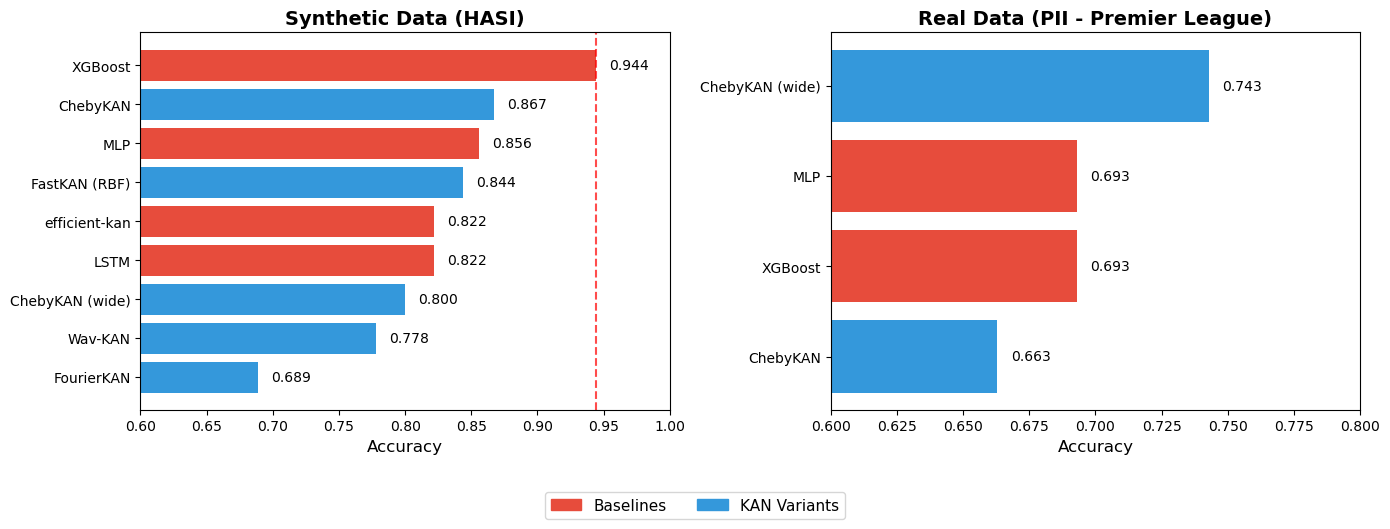


📊 Saved: figures/benchmark_publication_style.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# HASI Results
hasi_data = results[['Method', 'HASI (Acc)']].dropna().sort_values('HASI (Acc)', ascending=True)
colors1 = ['#3498db' if 'KAN' in m else '#e74c3c' for m in hasi_data['Method']]
axes[0].barh(hasi_data['Method'], hasi_data['HASI (Acc)'], color=colors1)
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Synthetic Data (HASI)', fontsize=14, fontweight='bold')
axes[0].set_xlim(0.6, 1.0)
axes[0].axvline(x=0.944, color='red', linestyle='--', alpha=0.7)
for i, (idx, row) in enumerate(hasi_data.iterrows()):
    axes[0].text(row['HASI (Acc)'] + 0.01, i, f"{row['HASI (Acc)']:.3f}", va='center', fontsize=10)

# PII Results
pii_data = results[['Method', 'PII (Acc)']].dropna().sort_values('PII (Acc)', ascending=True)
colors2 = ['#3498db' if 'KAN' in m else '#e74c3c' for m in pii_data['Method']]
axes[1].barh(pii_data['Method'], pii_data['PII (Acc)'], color=colors2)
axes[1].set_xlabel('Accuracy', fontsize=12)
axes[1].set_title('Real Data (PII - Premier League)', fontsize=14, fontweight='bold')
axes[1].set_xlim(0.6, 0.8)
for i, (idx, row) in enumerate(pii_data.iterrows()):
    axes[1].text(row['PII (Acc)'] + 0.005, i, f"{row['PII (Acc)']:.3f}", va='center', fontsize=10)

# Legend
baseline_patch = mpatches.Patch(color='#e74c3c', label='Baselines')
kan_patch = mpatches.Patch(color='#3498db', label='KAN Variants')
fig.legend(handles=[baseline_patch, kan_patch], loc='upper center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, 0.02))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('../figures/benchmark_publication_style.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n📊 Saved: figures/benchmark_publication_style.png")

---

## Conclusion

Our experiments demonstrate that **ChebyKAN** can outperform traditional machine learning methods on complex real-world tabular data:

1. **Synthetic Data**: XGBoost achieves best performance (94.4%), with ChebyKAN as top KAN variant (86.7%)
2. **Real Data**: ChebyKAN (wide) **outperforms XGBoost** by +5% (74.3% vs 69.3%)
3. **Architecture Insights**: Shallow networks with lower polynomial degrees (deg=4) work well on synthetic data; wider architectures excel on real data

These findings align with the TabKAN paper's conclusions that KAN-based methods offer competitive or superior performance on tabular classification tasks.